<a href="https://colab.research.google.com/github/sohamarora04/1BM23CS334MLLAB/blob/main/1BM23CS334_LAB11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
df_iris = pd.read_excel('/content/iris (1).xlsx')

print('Original Iris Dataset Head:')
display(df_iris.head())

Original Iris Dataset Head:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Select 'petal_width' and 'petal_length' features for clustering
X = df_iris[['petal_width', 'petal_length']]

print('\nSelected features for clustering:')
display(X.head())


Selected features for clustering:


,petal_width,petal_length
0,0.2,1.4
1,0.2,1.4
2,0.2,1.3
3,0.2,1.5
4,0.2,1.4


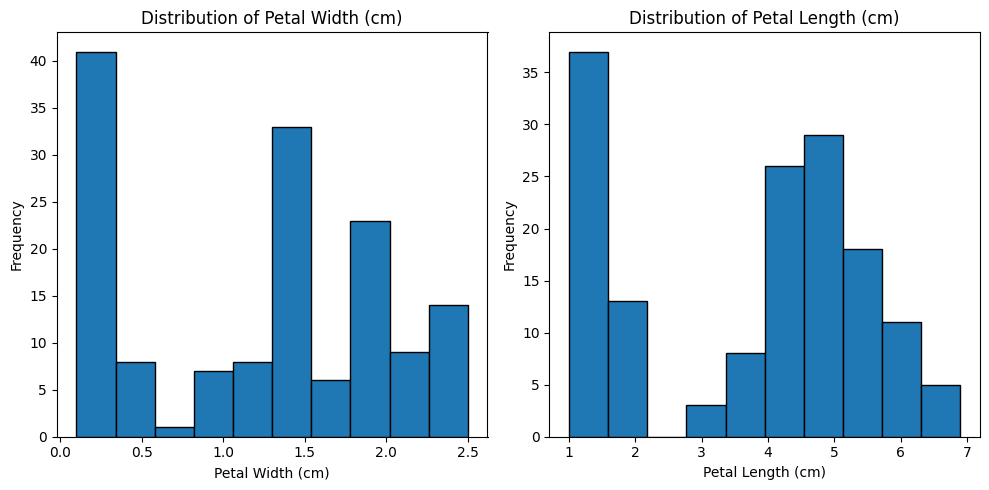


Descriptive statistics of the features:


,petal_width,petal_length
count,150.000000,150.000000
mean,1.198667,3.758667
std,0.763161,1.764420
min,0.100000,1.000000
25%,0.300000,1.600000
50%,1.300000,4.350000
75%,1.800000,5.100000
max,2.500000,6.900000


In [ ]:
# Visualize the distribution of the selected features
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(X['petal_width'], bins=10, edgecolor='black')
plt.title('Distribution of Petal Width (cm)')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(X['petal_length'], bins=10, edgecolor='black')
plt.title('Distribution of Petal Length (cm)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check basic statistics to see if scaling is needed
print('\nDescriptive statistics of the features:')
display(X.describe())

### Preprocessing Observation:
Based on the descriptive statistics, the ranges for petal width (0.1 to 2.5) and petal length (1.0 to 6.9) are somewhat different. While K-Means can handle small differences, scaling is generally good practice for distance-based algorithms to ensure all features contribute equally. Therefore, I will proceed with scaling the features.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\nScaled features (first 5 rows):')
display(pd.DataFrame(X_scaled, columns=X.columns).head())


Scaled features (first 5 rows):


,petal_width,petal_length
0,-1.312977,-1.341272
1,-1.312977,-1.341272
2,-1.312977,-1.398138
3,-1.312977,-1.284407
4,-1.312977,-1.341272


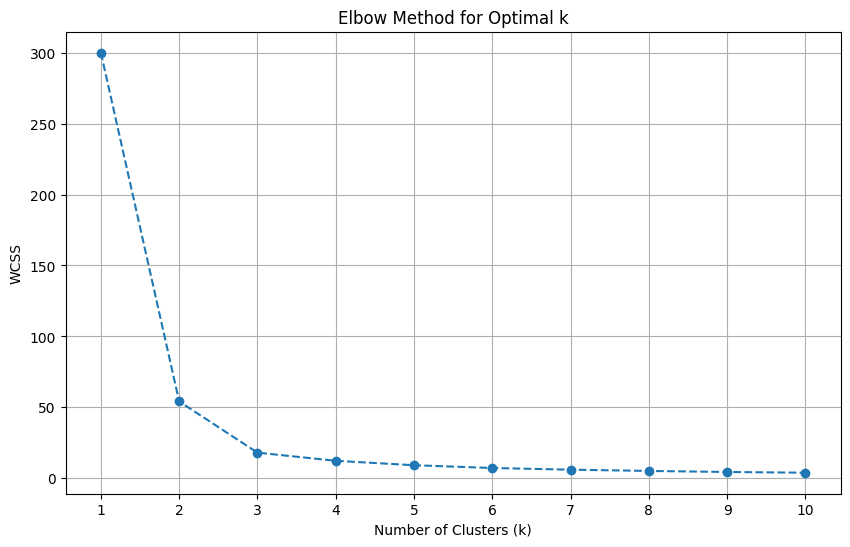

In [ ]:
# Determine the optimal number of clusters (k) using the Elbow Method
wcss = [] # Within-Cluster Sum of Squares

for i in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.xticks(range(1, 11))
plt.show()